# Desarrollo de Entrega Unidad 4 – Base de Datos de tienda usando las Unidades 9 y 10

En este caso trabajaremos con una base de datos de órdenes de bases de datos de tienda de la unidad 4.

Iniciemos importando las librerías necesarias

In [248]:
#!conda install sklearn -y
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from tqdm import tqdm
from sklearn.ensemble import IsolationForest
import plotly.express as px
import plotly.graph_objects as go

# Cargando y Analizando la Base de datos
Ahora importamos nuestra base de datos

In [249]:
consumer_data = pd.read_excel('data/Online Retail.xlsx')
consumer_data

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


# Cambiar los nombres de la base de datos creando un directorio 

In [250]:
from os import rename
consumer_data.rename(columns={'InvoiceNo':'Numero_factura','StockCode':'Cod_prod','Description':'Nombre_Producto','Quantity':'Cantidad','UnitPrice':'Precio unitario','InvoiceDate':'Fecha_compra','CustomerID':'Cod_Cliente','Country':'País'},inplace=True)
#consumer_data = pd.DataFrame(consumer_dat["Numero_factura"].astype(str))
#consumer_data.to_csv('data/Online_Retail.csv')
consumer_data

,Numero_factura,Cod_prod,Nombre_Producto,Cantidad,Fecha_compra,Precio unitario,Cod_Cliente,País
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


Se analiza la estadistica de las variables númericas

In [251]:
consumer_data.describe()

,Cantidad,Fecha_compra,Precio unitario,Cod_Cliente
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


Tipo de datos que se tienen

In [252]:
consumer_data.dtypes

Numero_factura             object
Cod_prod                   object
Nombre_Producto            object
Cantidad                    int64
Fecha_compra       datetime64[us]
Precio unitario           float64
Cod_Cliente               float64
País                          str
dtype: object

In [253]:
print('Cantidad de paises: ', consumer_data['País'].nunique())
print('Cantidad de productos: ', consumer_data['Cod_prod'].nunique())
print('Cantidad de usuarios: ', consumer_data['Cod_Cliente'].nunique())

Cantidad de paises:  38
Cantidad de productos:  4070
Cantidad de usuarios:  4372


C:\Users\adolp\AppData\Local\Temp\ipykernel_22624\69215693.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=paises_ordenes.values, y=paises_traducidos, palette='viridis',color='goldenrod')


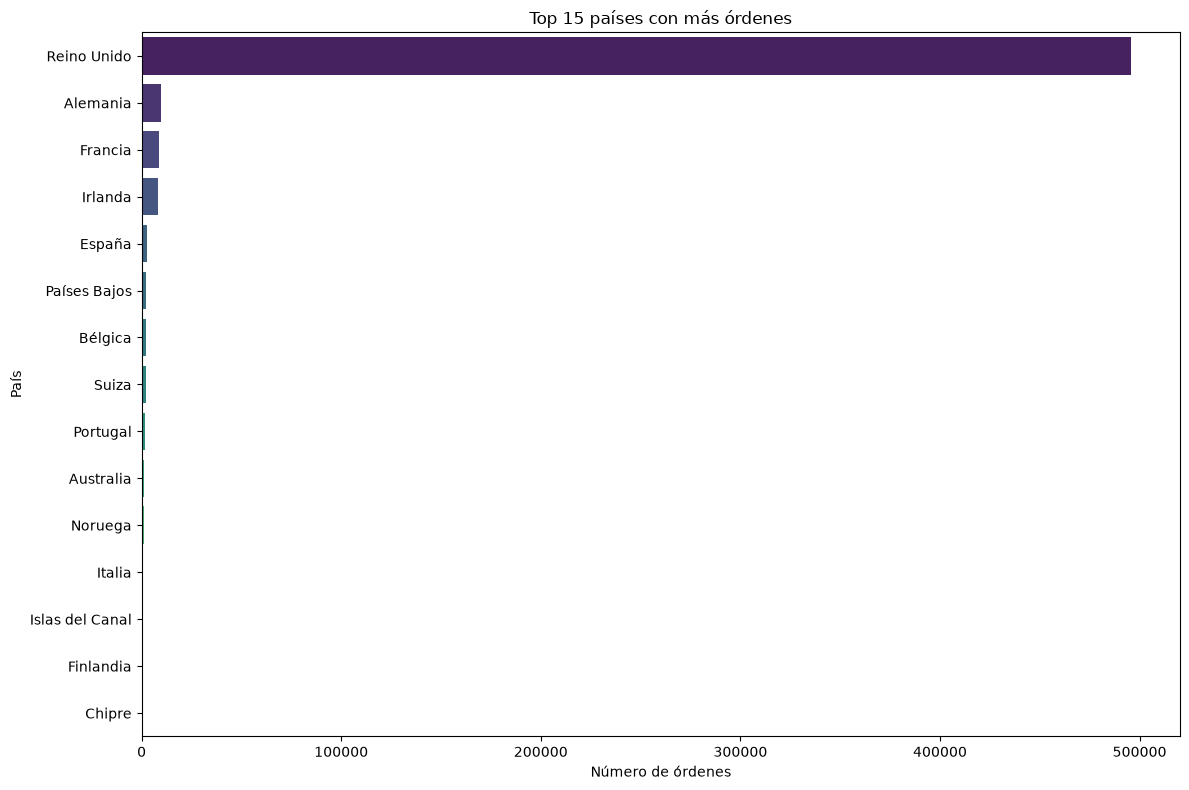

In [254]:
# Gráfica de órdenes por país con nombres en español
paises_ordenes = consumer_data['País'].value_counts().head(15)

traduccion_paises = {
    'United Kingdom': 'Reino Unido',
    'France': 'Francia',
    'Germany': 'Alemania',
    'Spain': 'España',
    'Poland': 'Polonia',
    'Netherlands': 'Países Bajos',
    'Belgium': 'Bélgica',
    'Switzerland': 'Suiza',
    'Portugal': 'Portugal',
    'Australia': 'Australia',
    'Norway': 'Noruega',
    'EIRE': 'Irlanda',
    'Sweden': 'Suecia',
    'Denmark': 'Dinamarca',
    'Finland': 'Finlandia',
    'Italy': 'Italia',
    'Channel Islands': 'Islas del Canal',
    'Cyprus': 'Chipre',    
}

paises_traducidos = [traduccion_paises.get(p, p) for p in paises_ordenes.index]

plt.figure(figsize=(12, 8))
sns.barplot(x=paises_ordenes.values, y=paises_traducidos, palette='viridis',color='goldenrod')
plt.title('Top 15 países con más órdenes')
plt.xlabel('Número de órdenes')
plt.ylabel('País')
plt.tight_layout()
plt.show()

Verifiquemos si tenemos valores faltantes en nuestra base de datos

In [255]:
consumer_data.isna().sum()

Numero_factura          0
Cod_prod                0
Nombre_Producto      1454
Cantidad                0
Fecha_compra            0
Precio unitario         0
Cod_Cliente        135080
País                    0
dtype: int64

# Tratamiento de la base de Datos
Teniendo en cuenta el código del producto se rellenaran los espacios

In [256]:
def completar_nombres_productos(df):
    """
    Rellena los espacios en blanco (valores nulos) de la columna 'Nombre_Producto' 
    buscando el nombre asociado a su 'Cod_prod' en el resto del DataFrame.
    """
    # 1. Creamos un mapeo (diccionario) de Cod_prod -> Nombre_Producto
    # Descartamos los nulos y nos quedamos con la primera aparición de cada producto
    mapeo_nombres = (
        df[['Cod_prod', 'Nombre_Producto']]
        .dropna(subset=['Nombre_Producto'])
        .drop_duplicates(subset=['Cod_prod'])
        .set_index('Cod_prod')['Nombre_Producto']
    )
    
    # 2. Rellenamos los valores nulos en 'Nombre_Producto' usando la función map() 
    # que busca el Cod_prod en nuestro mapeo
    df['Nombre_Producto'] = df['Nombre_Producto'].fillna(df['Cod_prod'].map(mapeo_nombres))
    
    return df

# funcion adicional 


# Ejemplo de uso con tu DataFrame:
consumer_data = completar_nombres_productos(consumer_data)

# Para verificar que funcionó (opcional):
print("Valores nulos en 'Nombre_Producto':", consumer_data['Nombre_Producto'].isnull().sum())


Valores nulos en 'Nombre_Producto': 112


Verificamos el resultado

In [257]:
consumer_data.isna().sum()

Numero_factura          0
Cod_prod                0
Nombre_Producto       112
Cantidad                0
Fecha_compra            0
Precio unitario         0
Cod_Cliente        135080
País                    0
dtype: int64

In [258]:
consumer_data

,Numero_factura,Cod_prod,Nombre_Producto,Cantidad,Fecha_compra,Precio unitario,Cod_Cliente,País
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


# Tener pendiente consumer_data_a para el analisis de algoritmos no descriptivos

In [259]:

# Reemplazar celdas vacías en Cod_Cliente por NaN
consumer_data_a = consumer_data.copy()
consumer_data_a['Cod_Cliente'] = consumer_data_a['Cod_Cliente'].replace(['', ' ', np.nan], np.nan)

# Mostrar el conteo de valores NaN después del reemplazo
print("Valores NaN después del reemplazo:")
print(consumer_data_a.isna().sum())
#print("\nValores únicos en Cod_Cliente (primeros 10):")
#print(consumer_data_a['Cod_Cliente'].unique()[:10])

Valores NaN después del reemplazo:
Numero_factura          0
Cod_prod                0
Nombre_Producto       112
Cantidad                0
Fecha_compra            0
Precio unitario         0
Cod_Cliente        135080
País                    0
dtype: int64


In [260]:
# Reemplazar valores vacíos en Cod_Cliente por NaN y eliminar filas de consumer_data
consumer_data['Cod_Cliente'] = consumer_data['Cod_Cliente'].replace(['', ' '], np.nan)

filas_antes = len(consumer_data)
filas_vacias = consumer_data['Cod_Cliente'].isna().sum()
print(f"Número de filas antes de eliminar: {filas_antes}")
print(f"Filas con Cod_Cliente vacío: {filas_vacias}")

# Eliminar filas con Cod_Cliente vacío en consumer_data
consumer_data = consumer_data.dropna(subset=['Cod_Cliente']).reset_index(drop=True)
filas_despues = len(consumer_data)
print(f"\nNúmero de filas después de eliminar: {filas_despues}")
print(f"Filas eliminadas: {filas_antes - filas_despues}")
print(f"Filas vacías restantes en Cod_Cliente: {consumer_data['Cod_Cliente'].isna().sum()}")

Número de filas antes de eliminar: 541909
Filas con Cod_Cliente vacío: 135080

Número de filas después de eliminar: 406829
Filas eliminadas: 135080
Filas vacías restantes en Cod_Cliente: 0


# Eliminar los datos duplicados 

In [261]:
consumer_data.drop_duplicates()

,Numero_factura,Cod_prod,Nombre_Producto,Cantidad,Fecha_compra,Precio unitario,Cod_Cliente,País
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
406824,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
406825,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
406826,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
406827,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


In [262]:
consumer_data.isna().sum()

Numero_factura     0
Cod_prod           0
Nombre_Producto    0
Cantidad           0
Fecha_compra       0
Precio unitario    0
Cod_Cliente        0
País               0
dtype: int64

Anexando una columna de estado de la compra

In [263]:
def asignar_estado_compra(df):
    """
    Crea una nueva columna 'Estado de la compra'.
    Si el 'Numero_factura' contiene la letra 'C', se marca como 'Cancelado', 
    de lo contrario se marca como 'Realizado'.
    """
    # 1. Nos aseguramos de tratar la columna Numero_factura como texto (string)
    # 2. Comprobamos si contiene la letra 'C' (case=False para que no distinga entre mayúsculas y minúsculas)
    condicion_cancelado = df['Numero_factura'].astype(str).str.contains('C', case=False, na=False)
    
    # 3. np.where funciona así: np.where(condicion, valor_si_verdadero, valor_si_falso)
    df['Estado de la compra'] = np.where(condicion_cancelado, 'Cancelado', 'Realizado')
    
    return df
# Ejemplo de uso con tu DataFrame:
consumer_data = asignar_estado_compra(consumer_data)
# Para verificar que funcionó viendo algunas filas canceladas:
display(consumer_data[consumer_data['Estado de la compra'] == 'Cancelado'].head())

,Numero_factura,Cod_prod,Nombre_Producto,Cantidad,Fecha_compra,Precio unitario,Cod_Cliente,País,Estado de la compra
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom,Cancelado
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom,Cancelado
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom,Cancelado
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom,Cancelado
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom,Cancelado


Se adiciona la linea para trasformar la columna Numero de Factura a tipo texto.  

In [264]:
consumer_data["Numero_factura"] = consumer_data["Numero_factura"].astype(str)
consumer_data["Cod_prod"] = consumer_data["Cod_prod"].astype(str)
consumer_data["Nombre_Producto"] = consumer_data["Nombre_Producto"].astype(str)
consumer_data


,Numero_factura,Cod_prod,Nombre_Producto,Cantidad,Fecha_compra,Precio unitario,Cod_Cliente,País,Estado de la compra
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,Realizado
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,Realizado
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,Realizado
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,Realizado
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,Realizado
...,...,...,...,...,...,...,...,...,...
406824,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,Realizado
406825,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,Realizado
406826,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,Realizado
406827,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,Realizado


Se realiza una la priemra grafica

se agrega las columnas fecha día mes hora

In [265]:
# 2. Creamos las nuevas columnas extrayendo la información
dias_semana = {
    0: 'Lunes', 1: 'Martes', 2: 'Miércoles',
    3: 'Jueves', 4: 'Viernes', 5: 'Sábado', 6: 'Domingo'
}
consumer_data['Dia_compra'] = consumer_data['Fecha_compra'].dt.dayofweek.map(dias_semana)

consumer_data['Mes_compra'] = consumer_data['Fecha_compra'].dt.month
meses_mapping = {
    1: 'Enero', 2: 'Febrero', 3: 'Marzo', 4: 'Abril',
    5: 'Mayo', 6: 'Junio', 7: 'Julio', 8: 'Agosto',
    9: 'Septiembre', 10: 'Octubre', 11: 'Noviembre', 12: 'Diciembre'
}
consumer_data['Mes_compra'] = consumer_data['Mes_compra'].map(meses_mapping)
consumer_data['Mes_compra'] = pd.Categorical(
    consumer_data['Mes_compra'],
    categories=list(meses_mapping.values()),
    ordered=True
)
consumer_data['Hora_compra'] = consumer_data['Fecha_compra'].dt.hour
# Para verificar que las columnas se crearon correctamente:
display(consumer_data[['Fecha_compra', 'Dia_compra', 'Mes_compra', 'Hora_compra']].head())
consumer_data

,Fecha_compra,Dia_compra,Mes_compra,Hora_compra
0,2010-12-01 08:26:00,Miércoles,Diciembre,8
1,2010-12-01 08:26:00,Miércoles,Diciembre,8
2,2010-12-01 08:26:00,Miércoles,Diciembre,8
3,2010-12-01 08:26:00,Miércoles,Diciembre,8
4,2010-12-01 08:26:00,Miércoles,Diciembre,8


,Numero_factura,Cod_prod,Nombre_Producto,Cantidad,Fecha_compra,Precio unitario,Cod_Cliente,País,Estado de la compra,Dia_compra,Mes_compra,Hora_compra
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,Realizado,Miércoles,Diciembre,8
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,Realizado,Miércoles,Diciembre,8
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,Realizado,Miércoles,Diciembre,8
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,Realizado,Miércoles,Diciembre,8
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,Realizado,Miércoles,Diciembre,8
...,...,...,...,...,...,...,...,...,...,...,...,...
406824,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,Realizado,Viernes,Diciembre,12
406825,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,Realizado,Viernes,Diciembre,12
406826,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,Realizado,Viernes,Diciembre,12
406827,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,Realizado,Viernes,Diciembre,12


<Axes: xlabel='Mes_compra'>

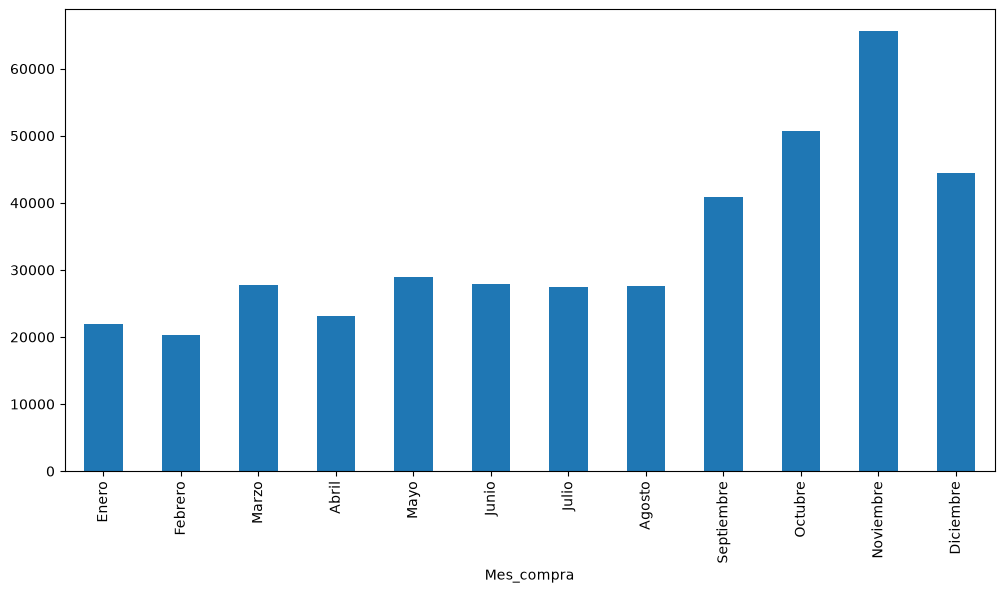

In [266]:
#consumer_data = consumer_data.order(columns={'1': 'Enero', '2': 'Febrero', '3': 'Marzo', '4': 'Abril', '5': 'Mayo', '6': 'Junio', '7': 'Julio', '8': 'Agosto', '9': 'Septiembre', '10': 'Octubre', '11': 'Noviembre', '12': 'Diciembre'})
consumer_data['Mes_compra'].value_counts().sort_index().plot(kind='bar', figsize=(12, 6))


In [267]:
consumer_data.describe()

,Cantidad,Fecha_compra,Precio unitario,Cod_Cliente,Hora_compra
count,406829.000000,406829,406829.000000,406829.000000,406829.000000
mean,12.061303,2011-07-10 16:30:57.879207,3.460471,15287.690570,12.737472
min,-80995.000000,2010-12-01 08:26:00,0.000000,12346.000000,6.000000
25%,2.000000,2011-04-06 15:02:00,1.250000,13953.000000,11.000000
50%,5.000000,2011-07-31 11:48:00,1.950000,15152.000000,13.000000
75%,12.000000,2011-10-20 13:06:00,3.750000,16791.000000,14.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000,20.000000
std,248.693370,NaN,69.315162,1713.600303,2.284952


se vuelve a ver que tipo de datos que tiene la base 

In [268]:
consumer_data.dtypes

Numero_factura                    str
Cod_prod                          str
Nombre_Producto                   str
Cantidad                        int64
Fecha_compra           datetime64[us]
Precio unitario               float64
Cod_Cliente                   float64
País                              str
Estado de la compra               str
Dia_compra                        str
Mes_compra                   category
Hora_compra                     int32
dtype: object

In [269]:
#consumer_data['Dia_compra'].order = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']
#consumer_data['Dia_compra'].value_counts().reindex(['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sabado', 'Domingo']).plot(kind='bar', figsize=(12, 6))
consumer_data['Dia_semana'] = consumer_data['Fecha_compra'].dt.day_name()

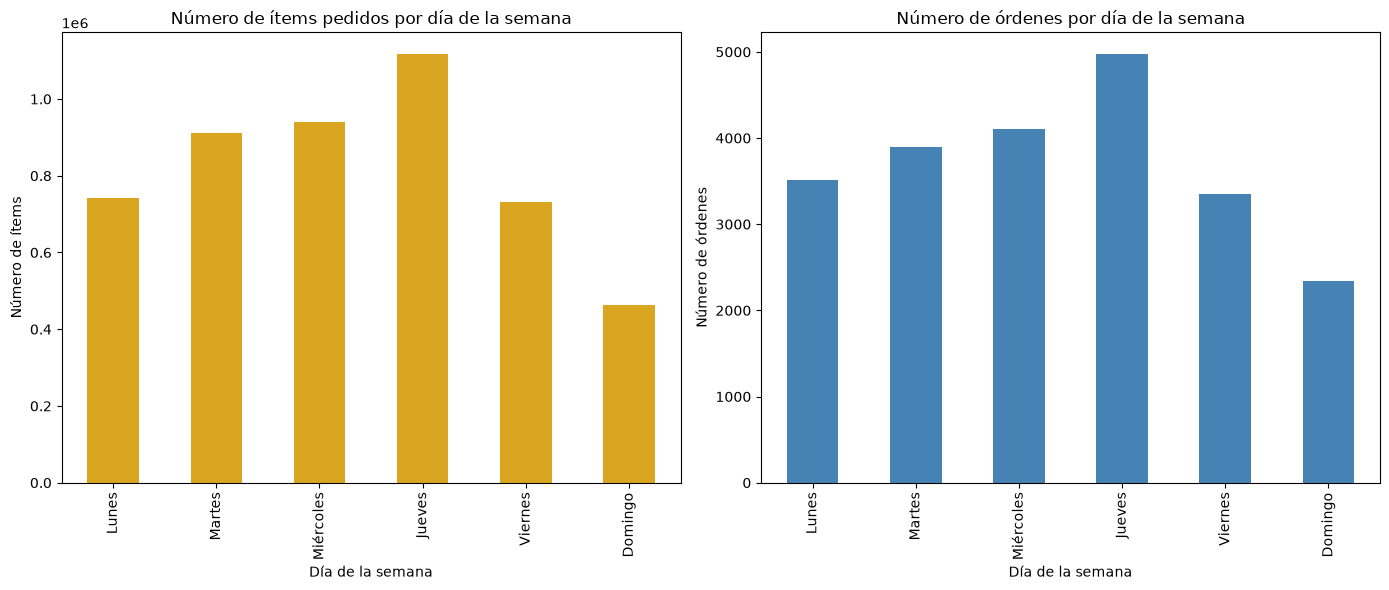

In [270]:
# 1. Crear la columna de día de la semana (en español, ordenada Lunes->Domingo)
dias_es = {0:'Lunes', 1:'Martes', 2:'Miércoles', 3:'Jueves', 4:'Viernes', 5:'Sábado', 6:'Domingo'}
consumer_data['Dia_semana'] = consumer_data['Fecha_compra'].dt.dayofweek.map(dias_es)
orden_dias = ['Lunes','Martes','Miércoles','Jueves','Viernes','Sábado','Domingo']
consumer_data['Dia_semana'] = pd.Categorical(consumer_data['Dia_semana'], categories=orden_dias, ordered=True)

# 2. Agregaciones correctas por día de la semana
items_por_dia = consumer_data.groupby('Dia_semana')['Cantidad'].sum()
ordenes_por_dia = consumer_data.groupby('Dia_semana')['Numero_factura'].nunique()

# 3. Graficar
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

items_por_dia.plot(kind='bar', ax=axes[0], color='goldenrod')
axes[0].set_title('Número de ítems pedidos por día de la semana')
axes[0].set_xlabel('Día de la semana')
axes[0].set_ylabel('Número de ítems')

ordenes_por_dia.plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('Número de órdenes por día de la semana')
axes[1].set_xlabel('Día de la semana')
axes[1].set_ylabel('Número de órdenes')

plt.tight_layout()
plt.show()

# Grafico de los paises a los cuales se envia los articulos 

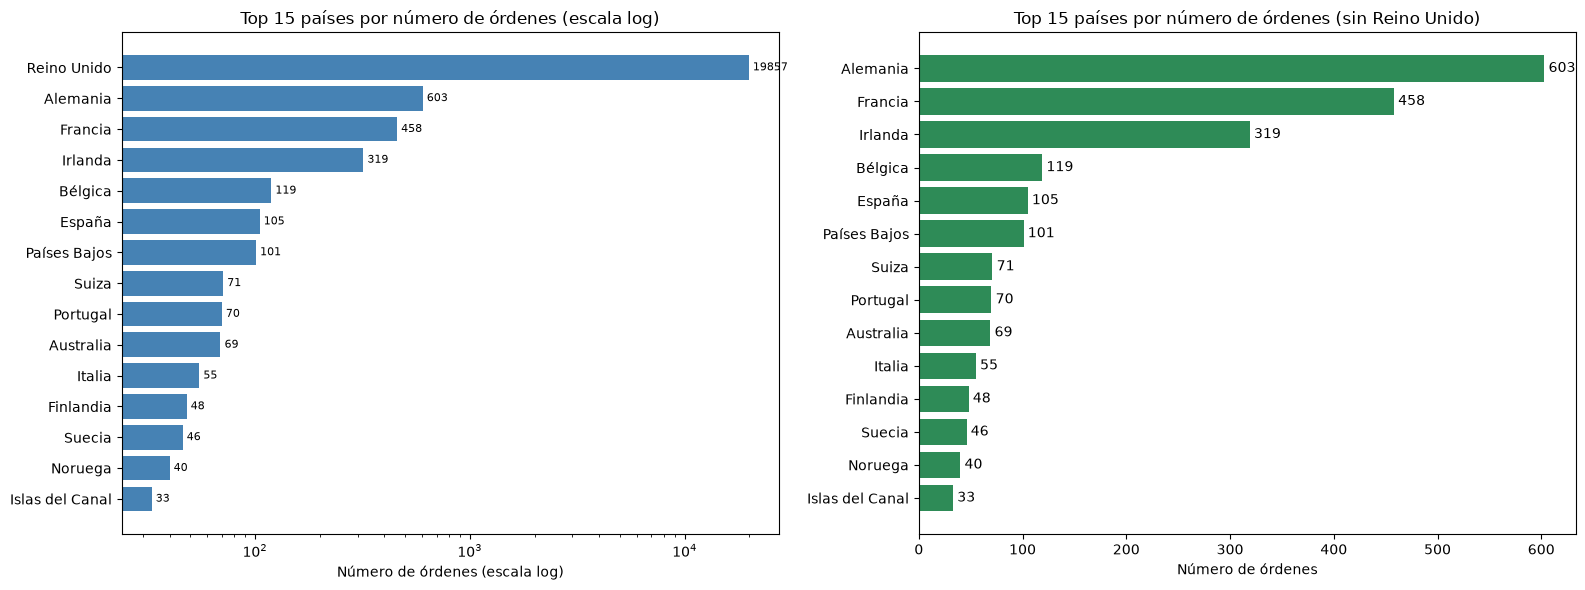

In [289]:

# Métrica correcta: facturas únicas, no filas
traduccion_paises = {
    'United Kingdom': 'Reino Unido',
    'France': 'Francia',
    'Germany': 'Alemania',
    'Spain': 'España',
    'Poland': 'Polonia',
    'Netherlands': 'Países Bajos',
    'Belgium': 'Bélgica',
    'Switzerland': 'Suiza',
    'Portugal': 'Portugal',
    'Australia': 'Australia',
    'Norway': 'Noruega',
    'EIRE': 'Irlanda',
    'Sweden': 'Suecia',
    'Denmark': 'Dinamarca',
    'Finland': 'Finlandia',
    'Italy': 'Italia',
    'Channel Islands': 'Islas del Canal',
    'Cyprus': 'Chipre',    
}

ordenes_por_pais = consumer_data.groupby('País')['Numero_factura'].nunique().sort_values(ascending=False)
top15 = ordenes_por_pais.head(15)
top15.index = [traduccion_paises.get(p, p) for p in top15.index]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].barh(top15.index[::-1], top15.values[::-1], color='steelblue')
axes[0].set_xscale('log')

axes[1].barh(top15_sin_uk.index[::-1], top15_sin_uk.values[::-1], color='seagreen')

axes[0].bar_label(axes[0].containers[0], fmt='%.0f', padding=3, fontsize=8)
axes[1].bar_label(axes[1].containers[0], fmt='%.0f', padding=3)

axes[0].set_title('Top 15 países por número de órdenes (escala log)')
axes[0].set_xlabel('Número de órdenes (escala log)')

top15_sin_uk = top15.drop('Reino Unido', errors='ignore')
axes[1].barh(top15_sin_uk.index[::-1], top15_sin_uk.values[::-1], color='seagreen')
axes[1].set_title('Top 15 países por número de órdenes (sin Reino Unido)')
axes[1].set_xlabel('Número de órdenes')

plt.tight_layout()
plt.show()


Analisis de Hora del día

C:\Users\adolp\AppData\Local\Temp\ipykernel_22624\1801127518.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=compras_por_hora.index, y=compras_por_hora.values, palette='mako')


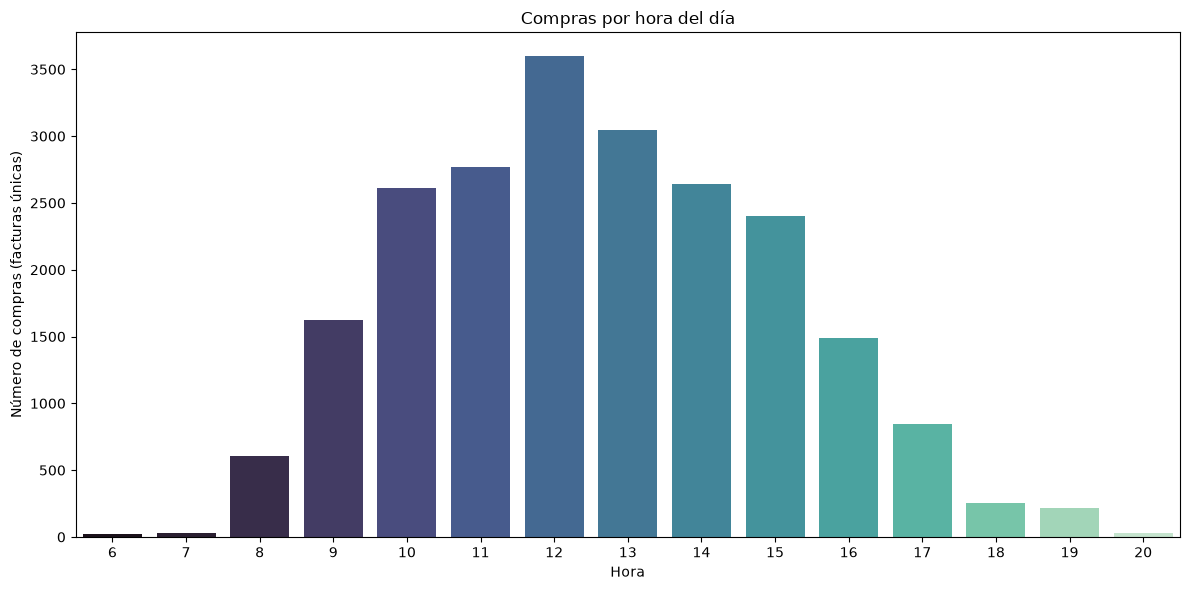

In [292]:
# Gráfico de compras por hora del día
compras_por_hora = consumer_data.groupby('Hora_compra')['Numero_factura'].nunique().sort_index()
plt.figure(figsize=(12, 6))
sns.barplot(x=compras_por_hora.index, y=compras_por_hora.values, palette='mako')
plt.title('Compras por hora del día')
plt.xlabel('Hora')
plt.ylabel('Número de compras (facturas únicas)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()